## **i. Mount google drive**
---

In [1]:
try:
    from google.colab import drive
    drive.mount('/content/gdrive')
except ImportError:
    print('Running locally; Google Drive mount is not required.')

Running locally; Google Drive mount is not required.


## **ii. Import the libraries**
---

In [2]:
import cv2
import sys
import os
import scipy
import matplotlib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


print("Versions of key libraries")
print("---")
print("numpy:     ", np.__version__)
print("matplotlib:", matplotlib.__version__)
print("pandas:    ", pd.__version__)
print("scipy:     ", scipy.__version__)


Versions of key libraries
---
numpy:      2.5.3
matplotlib: 3.11.2
pandas:     3.0.6
scipy:      1.18.1


## **iii. Append /iss/issm/data/ in your python path**
---

In [3]:
data_path = os.getcwd()
sys.path.append(data_path)
print("All the system paths:")
sys.path

All the system paths:


['C:\\Users\\Setekh\\miniconda3\\envs\\isy5002\\python312.zip',
 'C:\\Users\\Setekh\\miniconda3\\envs\\isy5002\\DLLs',
 'C:\\Users\\Setekh\\miniconda3\\envs\\isy5002\\Lib',
 'C:\\Users\\Setekh\\miniconda3\\envs\\isy5002',
 '',
 'C:\\Users\\Setekh\\miniconda3\\envs\\isy5002\\Lib\\site-packages',
 'C:\\Users\\Setekh\\Desktop\\ISY5002\\Part3\\Day1']

## **iv. Change working directory to /iss/issm/data/**
---

In [4]:
os.chdir(data_path)
print("Current working directory:")
os.getcwd()

Current working directory:


'C:\\Users\\Setekh\\Desktop\\ISY5002\\Part3\\Day1'

## **v. Setup matplotlib**
---

In [5]:
plt.style.use('ggplot')                   # if want to use the default style, set 'classic'
plt.rcParams['ytick.right']     = True
plt.rcParams['ytick.labelright']= True
plt.rcParams['ytick.left']      = False
plt.rcParams['ytick.labelleft'] = False

print("Matplotlib setup completes.")

Matplotlib setup completes.


## **1. Create 3 plot functions**
---
* `pltDistances`: For distance matrix and accumulated cost matrix
* `pltCostAndPath`: Plot accumulated cost matrix together with the optimal path
* `pltWarp`: Plot point-to-point connection between two signals

In [6]:
def pltDistances(dists,xlab="X",ylab="Y",clrmap="viridis"):
    imgplt  = plt.figure()
    plt.imshow(dists,
               interpolation='nearest',
               cmap=clrmap)
    
    plt.gca().invert_yaxis()    # This is added so that the y axis start from bottom, instead of top
    plt.xlabel(xlab)
    plt.ylabel(ylab)
    plt.grid()
    plt.colorbar()
    
    return imgplt

# ..........

def pltCostAndPath(acuCost,path,xlab="X",ylab="Y",clrmap="viridis"):
    px      = [pt[0] for pt in path]
    py      = [pt[1] for pt in path]
    
    imgplt  = pltDistances(acuCost,
                           xlab=xlab,
                           ylab=ylab,
                           clrmap=clrmap)  
    plt.plot(px,py)
    
    return imgplt

# ..........

def pltWarp(s1,s2,path,xlab="idx",ylab="Value"):
    imgplt      = plt.figure()
    
    for [idx1,idx2] in path:
        plt.plot([idx1,idx2],[s1[idx1],s2[idx2]],
                 color="C4",
                 linewidth=2)
    plt.plot(s1,
             'o-',
             color="C0",
             markersize=3)
    plt.plot(s2,
             's-',
             color="C1",
             markersize=2)
    
    plt.xlabel(xlab)
    plt.ylabel(ylab)
    
    return imgplt

print(pltDistances)
print(pltCostAndPath)
print(pltWarp)

<function pltDistances at 0x000001E92CB40C20>
<function pltCostAndPath at 0x000001E92CB41080>
<function pltWarp at 0x000001E92CB41120>


## **2. Create functions to compute distance matrix and accumulated cost matrix**
---


In [7]:
def computeDists(x,y):
    dists       = np.zeros((len(y),len(x)))
    
    for i in range(len(y)):
        for j in range(len(x)):
            dists[i,j]  = (y[i]-x[j])**2
            
    return dists


# ..............


def computeAcuCost(dists):
    acuCost     = np.zeros(dists.shape)
    acuCost[0,0]= dists[0,0]
                                                # Calculate the accumulated costs along the first row
    for j in range(1,dists.shape[1]):           # the running number starts from 1, not 0
        acuCost[0,j]    = dists[0,j]+acuCost[0,j-1]
        
                                                # Calculate the accumulated costs along the first column
    for i in range(1,dists.shape[0]):           # the running number starts from 1, not 0
        acuCost[i,0]    = dists[i,0]+acuCost[i-1,0]    
    
                                                # Calculate the accumulated costs from second column, row onwards    
    for i in range(1,dists.shape[0]):
        for j in range(1,dists.shape[1]):
            acuCost[i,j]    = min(acuCost[i-1,j-1],
                                  acuCost[i-1,j],
                                  acuCost[i,j-1])+dists[i,j]
            
    return acuCost

print(computeDists)
print(computeAcuCost)

<function computeDists at 0x000001E92CB41300>
<function computeAcuCost at 0x000001E92CB411C0>


## **3. Create the function to perform dynamic time warping (to be completed)**
---

In [8]:
# Type your code below


def doDTW(x,y,dists,acuCost):
    i = len(y)-1
    j = len(x)-1
    path = [[j,i]]

    while (i > 0) or (j > 0):
        if i == 0:
            j = j-1
        elif j == 0:
            i = i-1
        else:
            choices = [acuCost[i-1,j-1], acuCost[i-1,j], acuCost[i,j-1]]
            move = np.argmin(choices)
            if move == 0:
                i = i-1
                j = j-1
            elif move == 1:
                i = i-1
            else:
                j = j-1
        path.append([j,i])

    cost = sum(dists[i,j] for [j,i] in path)
    return path,cost

print(doDTW)

<function doDTW at 0x000001E92CB413A0>


## **4. Extract ECG segments (to be completed)**
---
* Step 1: Load ECG signals
* Step 2: Perform peak detection
* Step 3: Extract ECG segments based on the detected peaks

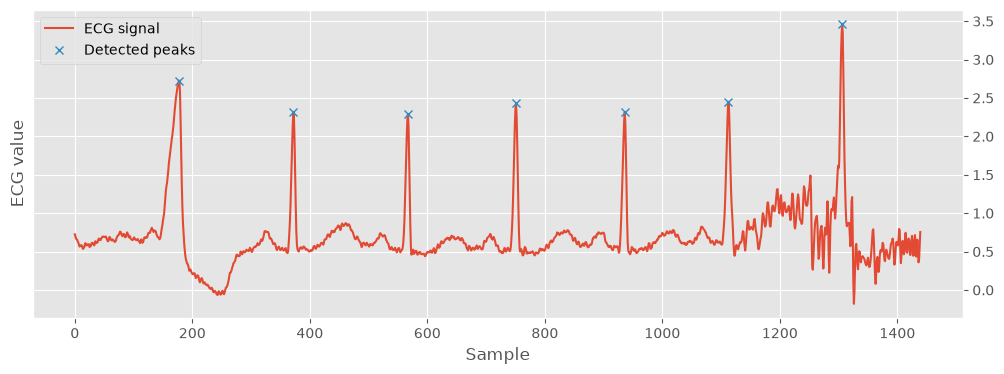

Number of detected peaks: 7
Number of ECG segments: 6
Length of each segment: [195, 195, 184, 185, 176, 194]


In [9]:
# Type your code below

from scipy.signal import find_peaks as findPeaks

# Load the second ECG signal from the supplied data file
l2D = pd.read_csv('ecg2D.csv', header=None)
ECGs = l2D[1].values

# Detect the main heartbeat peaks
Pks, _ = findPeaks(ECGs, distance=120, prominence=1.0)

def extractECG(ecg,pks,offset=15):
    segs = []
    if pks[0]-offset < 0:
        start = 1
    else:
        start = 0

    for i in range(start,len(pks)-1):
        seg = ecg[(pks[i]-offset):(pks[i+1]-offset)]
        segs.append(seg)

    return segs

EcgSegs = extractECG(ECGs,Pks)

plt.figure(figsize=(12,4))
plt.plot(ECGs, label='ECG signal')
plt.plot(Pks, ECGs[Pks], 'x', label='Detected peaks')
plt.xlabel('Sample')
plt.ylabel('ECG value')
plt.legend()
plt.show()

print('Number of detected peaks:', len(Pks))
print('Number of ECG segments:', len(EcgSegs))
print('Length of each segment:', [len(seg) for seg in EcgSegs])


## **5.Perform dynamic time warping on ECG segments (to be completed)**
---

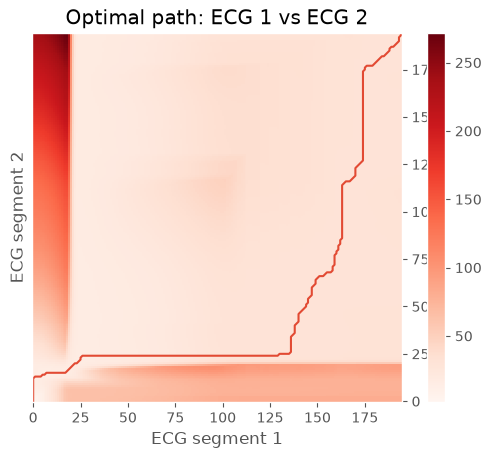

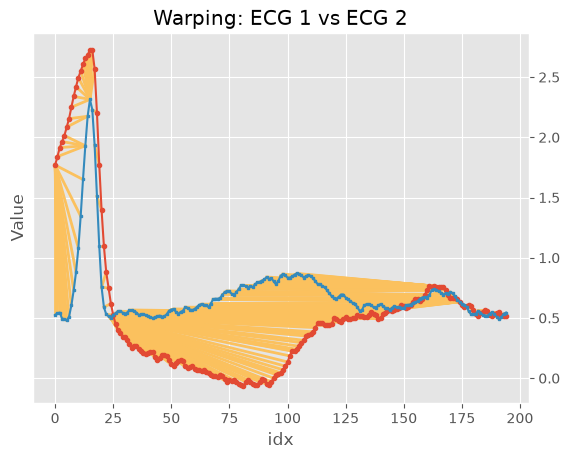

The accumulated cost between ECG 1 and 2 is 29.936700


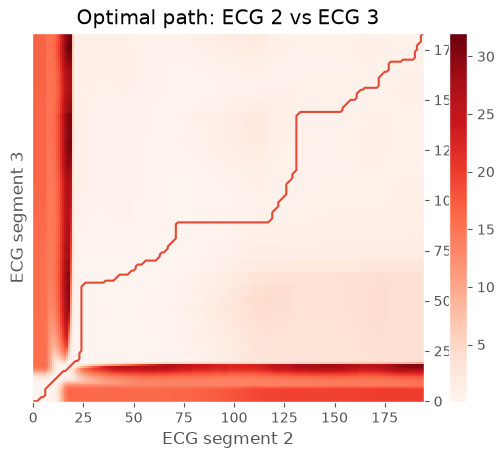

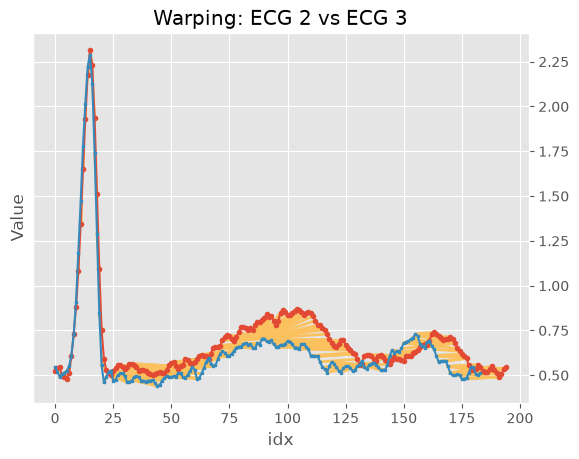

The accumulated cost between ECG 2 and 3 is 0.759900


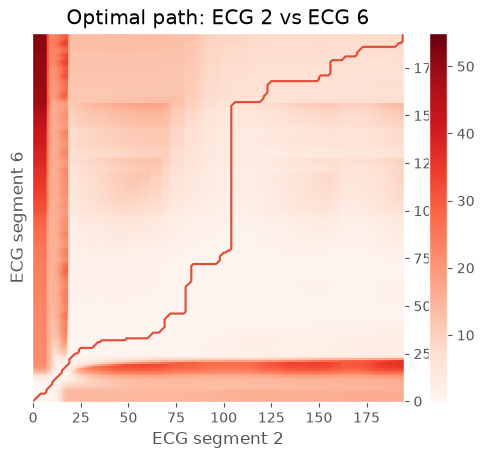

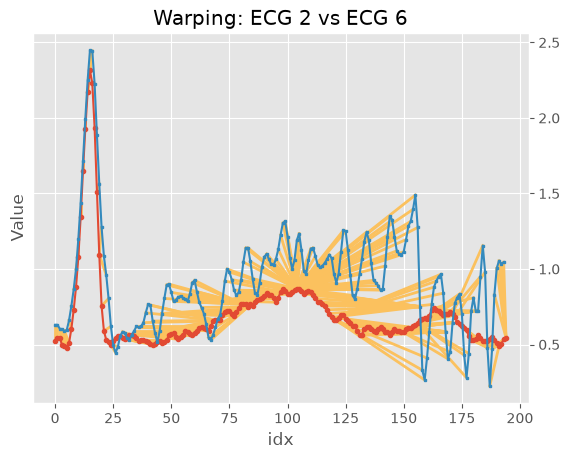

The accumulated cost between ECG 2 and 6 is 8.395275


In [10]:
# Type your code below

def compareECG(first,second):
    x = EcgSegs[first-1]
    y = EcgSegs[second-1]
    dists = computeDists(x,y)
    acuCost = computeAcuCost(dists)
    path, cost = doDTW(x,y,dists,acuCost)

    pltCostAndPath(acuCost,path,
                   xlab='ECG segment %d' % first,
                   ylab='ECG segment %d' % second,
                   clrmap='Reds')
    plt.title('Optimal path: ECG %d vs ECG %d' % (first,second))
    plt.show()

    pltWarp(x,y,path)
    plt.title('Warping: ECG %d vs ECG %d' % (first,second))
    plt.show()

    print('The accumulated cost between ECG %d and %d is %f' % (first,second,cost))
    return cost

cost12 = compareECG(1,2)
cost23 = compareECG(2,3)
cost26 = compareECG(2,6)
